In [1]:
%%capture
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [2]:
from google.colab import userdata
api_key = userdata.get('cos_api_key')

In [4]:
import pandas as pd
exchange = pd.read_csv('/content/exchange_sun.csv')

# 외환보유액 가설 재검증 (4, 4-1, 5, 6) : 외화 변화량으로 다시 확인

[가설 4] 외화보유액이 증가할수록 환율은 떨어질 것이다.

[가설 4-1] 경제심리지수가 낮아질수록 외환보유액은 증가할 것이다

[가설 5] 외환보유액과 환율은 정책적 이벤트에 영향을 받는다.

[가설 6] 외국인 투자금액이 늘면 외환보유액이 증가한다.


**왜?**
- 결국 외화보유액은 누적되는 것이므로 확실하게 영향을 받아 얼마나 변화하는지 봐야함.

- 목적이 영향 관계 이므로 원인 -> 결과 (변화량) 으로 분석해보기로 했다.

- "외국인 투자자금이 얼마나 유입되었는가 → 그에 따라 외환보유액이 얼마나 바뀌었는가" : 인과 해석

In [12]:
# 외환보유액 변화량 계산
exchange['외환보유액_변화'] = exchange['한국 외환 보유액'].diff()

# 상관계수 계산 (다른 변수는 원시값 사용)
corr_4 = exchange[['외환보유액_변화', '원/달러환율']].corr().iloc[0, 1]
corr_4_1 = exchange[['경제 심리 지수','외환보유액_변화']].corr().iloc[0, 1]
corr_6 = exchange[['외국인 투자 금액','외환보유액_변화']].corr().iloc[0, 1]

print(f"[가설 4] 외환보유액 변화 ↔ 환율 상관계수: {corr_4:.3f}")
print(f"[가설 4-1] 외환보유액 변화 ↔ 경제심리지수 상관계수: {corr_4_1:.3f}")
print(f"[가설 6] 외환보유액 변화 ↔ 외국인 투자금액 상관계수: {corr_6:.3f}")

[가설 4] 외환보유액 변화 ↔ 환율 상관계수: -0.205
[가설 4-1] 외환보유액 변화 ↔ 경제심리지수 상관계수: 0.139
[가설 6] 외환보유액 변화 ↔ 외국인 투자금액 상관계수: -0.143


In [14]:
# TIME 컬럼을 datetime으로 변환 (필요 시)
exchange["TIME"] = pd.to_datetime(exchange["TIME"].astype(str))  # Period → datetime 변환

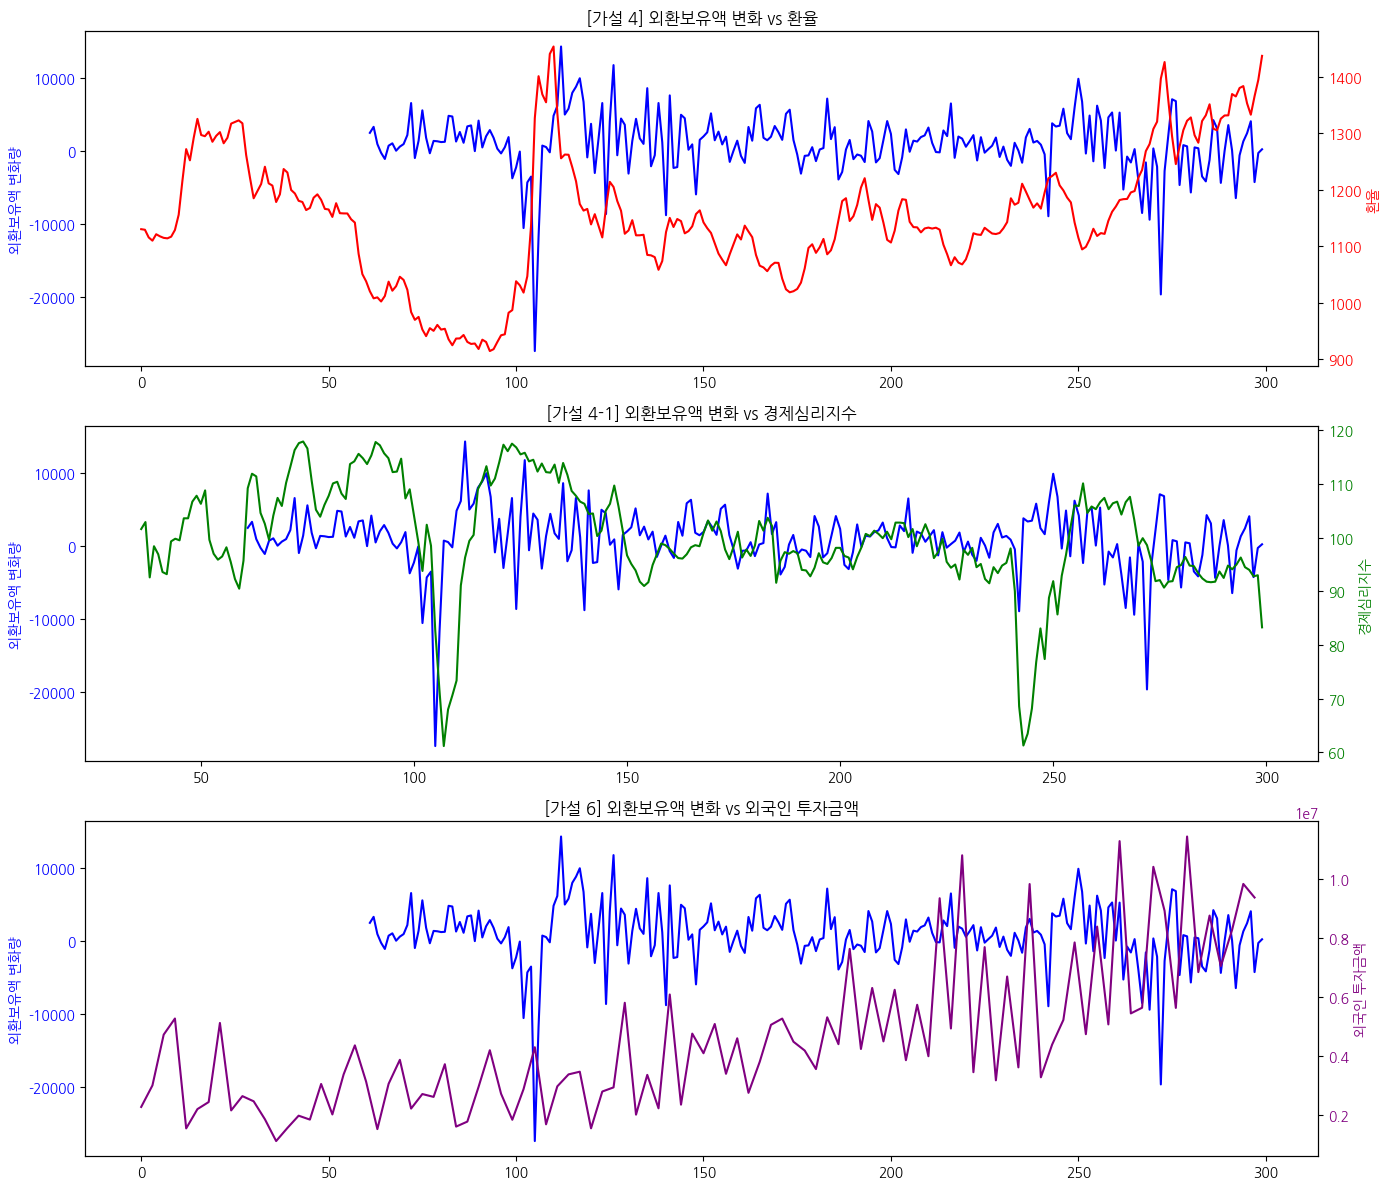

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 가설 4: 외환보유액 변화 vs 환율
ax1 = axes[0]
ax1.plot(exchange.index, exchange['외환보유액_변화'], color='blue', label='외환보유액 변화량')
ax1.set_ylabel('외환보유액 변화량', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1b = ax1.twinx()
ax1b.plot(exchange.index, exchange['원/달러환율'], color='red', label='환율')
ax1b.set_ylabel('환율', color='red')
ax1b.tick_params(axis='y', labelcolor='red')

ax1.set_title('[가설 4] 외환보유액 변화 vs 환율')

# 가설 4-1: 외환보유액 변화 vs 경제심리지수
ax2 = axes[1]
ax2.plot(exchange.index, exchange['외환보유액_변화'], color='blue', label='외환보유액 변화량')
ax2.set_ylabel('외환보유액 변화량', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2b = ax2.twinx()
ax2b.plot(exchange.index, exchange['경제 심리 지수'], color='green', label='경제심리지수')
ax2b.set_ylabel('경제심리지수', color='green')
ax2b.tick_params(axis='y', labelcolor='green')

ax2.set_title('[가설 4-1] 외환보유액 변화 vs 경제심리지수')

# 가설 6: 외환보유액 변화 vs 외국인 투자금액
ax3 = axes[2]
ax3.plot(exchange.index, exchange['외환보유액_변화'], color='blue', label='외환보유액 변화량')
ax3.set_ylabel('외환보유액 변화량', color='blue')
ax3.tick_params(axis='y', labelcolor='blue')

ax3b = ax3.twinx()
ax3b.plot(exchange.index, exchange['외국인 투자 금액'], color='purple', label='외국인 투자금액')
ax3b.set_ylabel('외국인 투자금액', color='purple')
ax3b.tick_params(axis='y', labelcolor='purple')

ax3.set_title('[가설 6] 외환보유액 변화 vs 외국인 투자금액')

plt.tight_layout()
plt.show()

## **[가설 4] 외환보유액 변화량 vs 환율**

**그래프 해석**

- 환율(빨간색)은 전체적으로는 상승 추세이지만, 외환보유액 변화량(파란색)은 그와 뚜렷한 반대 흐름 없이 진폭이 큰 형태.

- 큰 폭의 외환보유액 감소(예: 금융위기, 2022년) 이후에도 환율은 일부 시점에선 되려 안정되거나 상승 지속.

**결론**

- 외환보유액이 늘어난다고 해서 환율이 반드시 하락하지는 않음.

- 특히 외환보유액 변화량 기준에서는 환율과의 단기적 직접 연계성이 낮으며, 오히려 사후 대응적 성격(=환율 상승 → 보유액 변화)이 강함.

  → 가설 4는 약하게만 지지됨, 반대 인과관계 가능성도 존재.
<br>

## **[가설 4-1] 외환보유액 변화량 vs 경제심리지수**

**그래프 해석**

- 외환보유액 변화량(파란색)과 경제심리지수(초록색)는 전반적으로 유사한 진폭을 가지며, 위기 시점에서 동반 하락 또는 반응하는 구간이 관찰됨 (예: 2008, 2020, 2022).

- 다만 평상시 구간에서는 큰 연계성은 관찰되지 않음.

**결론**

- 심리 위축기(지수 하락 시)에 외환보유액이 급변(감소)하는 구간이 존재하며, 경제심리지수는 위기 상황에서 보유액 급감과 일정한 관계가 있는 것으로 보임.
  → 가설 4-1은 위기 상황에선 지지됨, 그러나 일반 시점에선 약함.

<br>

## **[가설 6] 외국인 투자금액 vs 외환보유액 변화량**

**그래프 해석**

- 외국인 투자금액(보라색)은 장기적으로 완만한 증가세를 보이나 변동성이 큼.

- 외환보유액 변화량(파란색)은 특정 시점에서 급격한 진폭을 보이지만, 외국인 투자 흐름과 명확한 시계열 상 일치는 드러나지 않음.

**결론**

- 외국인 투자금액은 외환보유액에 기여할 수 있는 유입 요소 중 하나이지만, 직접적인 단기적 영향력을 판단하긴 어려움.

  → 가설 6은 장기적 추세에선 지지되나, 변화량 기준으로는 제한적 관계만 확인 가능함.

- [가설 5] 외환보유액과 환율은 정책적 이벤트에 영향을 받는다.

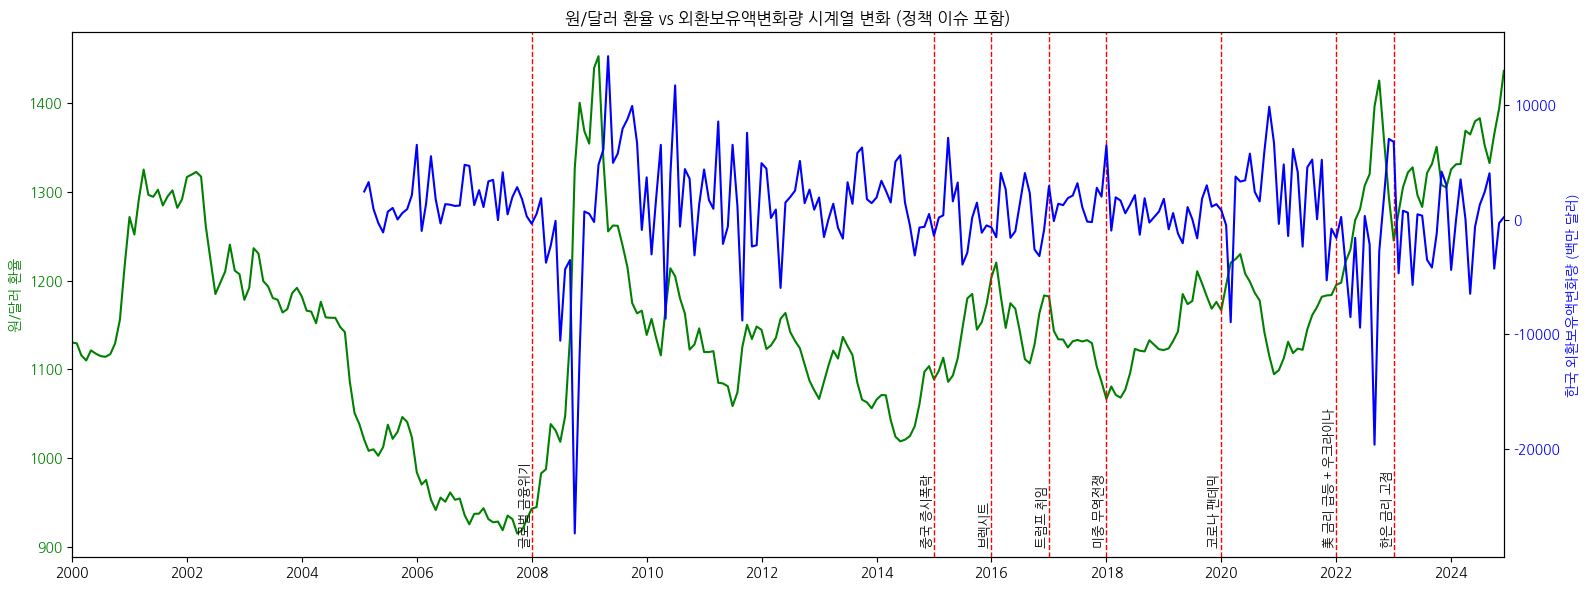

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 이벤트 연도 및 라벨
event_years = {
    "2008": "글로벌 금융위기",
    "2015": "중국 증시폭락",
    "2016": "브렉시트",
    "2017": "트럼프 취임",
    "2018": "미중 무역전쟁",
    "2020": "코로나 팬데믹",
    "2022": "美 금리 급등 + 우크라이나",
    "2023": "한은 금리 고점"
}

# 그래프 생성
fig, ax1 = plt.subplots(figsize=(16, 6))

# 왼쪽 축: 원/달러 환율
ax1.plot(exchange['TIME'], exchange['원/달러환율'], color='green', label='원/달러 환율')
ax1.set_ylabel('원/달러 환율', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# 오른쪽 축: 외환보유액
ax2 = ax1.twinx()
ax2.plot(exchange['TIME'], exchange['외환보유액_변화'], color='blue', label='외환보유액변화량 (백만 달러)')
ax2.set_ylabel('한국 외환보유액변화량 (백만 달러)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 제목
plt.title("원/달러 환율 vs 외환보유액변화량 시계열 변화 (정책 이슈 포함)")

# 정책 이벤트 수직선과 라벨 표시 (안겹치도록 아래쪽으로)
for i, (year, label) in enumerate(event_years.items()):
    date = pd.to_datetime(f"{year}-01-01")
    ax1.axvline(date, color='red', linestyle='--', linewidth=1)
    ax1.text(date, ax1.get_ylim()[0] + 10, label, rotation=90,
             verticalalignment='bottom', horizontalalignment='right',
             fontsize=9, color='black')

# x축 연도 포맷 설정
ax1.set_xlim([exchange['TIME'].min(), exchange['TIME'].max()])
ax1.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


| 시점         | 주요 정책 이벤트           | 환율 변화                          | 외환보유액 변화                | 해석 요약 |
|--------------|----------------------------|------------------------------------|-------------------------------|------------|
| 2008         | 글로벌 금융위기            | 급등 (불안심리, 원화 약세)         | 급감 후 반등                  | 위기 대응 위한 보유액 사용 후 방어 |
| 2015         | 중국 증시 폭락             | 상승                                | 일시적 감소                   | 아시아 불안, 심리적 방어 |
| 2016         | 브렉시트                   | 소폭 상승                           | 큰 변화 없음                  | 국내 영향 제한적 |
| 2017         | 트럼프 취임                | 보합                                | 보합                           | 정치적 불확실성, 영향 미미 |
| 2018         | 미중 무역전쟁              | 점진적 상승                         | 점진적 감소                   | 불확실성 확대, 유출 방어 |
| 2020         | 코로나 팬데믹              | 급등 (~1300원대)                    | 급감                           | 위기 시 보유액 방어성 사용 |
| 2022         | 美 금리 급등 + 우크라이나 전쟁 | 급등 (~1400원 이상)               | 급감                           | 외국인 유출 + 방어 지출 |
| 2023         | 韓 기준금리 고점           | 환율 하락 후 재상승                | 회복 지연                     | 금리 하락 기대, 방어 한계 노출 |


- 정책 이벤트 시점(빨간 점선)마다 외환보유액의 급격한 증감과 환율의 급변이 관측됨.

- 특히 글로벌 금융위기(2008), 코로나 팬데믹(2020), **미국 금리 급등+우크라이나 전쟁(2022)**에서는 환율 급등 + 외환보유액 급감이 동시에 발생.

  이는 외환시장 방어를 위한 정책적 개입으로 해석 가능.

- 하지만 **최근(2023~)**에는 환율이 일정 수준에서 유지되는데도 외환보유액 회복이 더딤.

  이는 정책 대응 한계 혹은 외화 유입 둔화로 해석 가능.

[가설 5] 외환보유액과 환율은 정책 이벤트에 영향을 받는다

**결론**


- 주요 정책 이벤트(금리 급등, 전쟁, 팬데믹 등)가 발생할 때,

  ▶ 환율 급등과 외환보유액 급감이 반복적으로 나타남.

- 이는 중앙은행의 외환시장 개입 시기와 정확히 일치하며,

  ▶ 외환보유액은 정책적 대응의 수단이자 정책 이벤트 반응 지표로 작용.

▶ 외환보유액은 정책 충격에 민감하게 반응한다는 점에서, 해당 가설은 타당하며 유의미한 설명력을 가짐.